Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist
%matplotlib inline

# Bayesian linear classifiers

In this example you are going to fit a Bayesian logistic regression model, using two sets of features on data $\mathbf{x} \in \mathbb{R}^2.

The first one is a "simple" set of features, with just the two input features plus an intercept:

$$\begin{align*}
\phi_{\text{simple}}(\mathbf{x}) &= [ 1, x_1, x_2 ]
\end{align*}$$

The second is up to you! For example, you could consider a set of quadratic polynomial features,

$$\begin{align*}
\phi_{\text{quadratic}}(\mathbf{x}) &= [ 1, x_1, x_2, x_1x_2, x_1^2, x_2^2 ].
\end{align*}$$

This example just includes quadratic terms, but you could also include higher order polynomial terms (e.g. $x_1^3, x_2^3$) or completely different features alltogether. It's up to you — but you should be prepared to justify your choice!

You will also fit the model in two different ways:

1. MAP estimation (penalized maximum likelihood)
2. Laplace approximation (a Gaussian approximate posterior, centered at the mode)

Here is a synthetic dataset that we'll be working with (plotting the training set only):

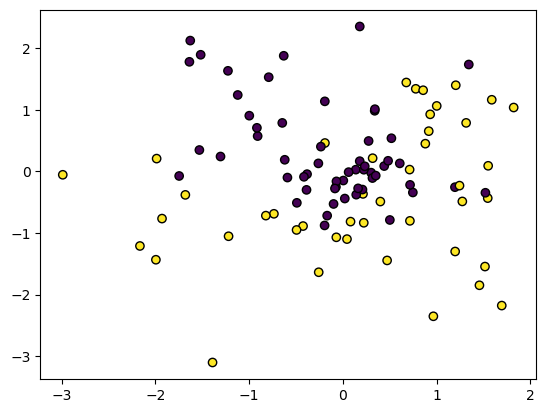

In [2]:
X_train, y_train, X_test, y_test = torch.load("data.pt")
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolors='k');
plt.show()

Here are definitions of two different feature maps, the "simple" one and the "quadratic" one.

They define feature spaces in $\mathbb{R}^3$ and $\mathbb{R}^6$, respectively.

In [3]:
def features_simple(X):
    return torch.concat((torch.ones_like(X[:,:1]), X), -1)

def features_quadratic(X):
    interactions = X.prod(-1, keepdim=True)
    return torch.concat((torch.ones_like(X[:,:1]), 
                         X, X.pow(2), interactions), -1)

print("Dimension of Phi, `features_simple`:", features_simple(X_train).shape)
print("Dimension of Phi, `features_quadratic`:", features_quadratic(X_train).shape)

Dimension of Phi, `features_simple`: torch.Size([100, 3])
Dimension of Phi, `features_quadratic`: torch.Size([100, 6])


# TASK #1 (3 points): Define the model

The Bayesian logistic regression model we are working with has the form
$$\begin{align*}
\mathbf{w} &\sim \mathcal{N}(0, \sigma^2 \mathbf{I}) \\
\hat y_i &= \mathrm{Logistic}(\mathbf{w}^\top \phi(\mathbf{x}_i)) \\
y_i &\sim \mathrm{Bernoulli}(\hat y_i)
\end{align*}$$
where $i = 1,\dots, N$ and the Logistic function is defined
$$\begin{align*}
\mathrm{Logistic}(z) &= \frac{1}{1 + \exp\{-z\}}.
\end{align*}$$
It's implemented in pytorch as `torch.sigmoid`.

The first step is to define two functions, one to make predictions given a weight vector $\mathbf{w}$ and inputs $\Phi$, and one which computes the log joint probability

$$\log p(\mathbf{y}, \mathbf{w} | \mathbf{\Phi}, \sigma^2).$$

I've done the first one for you.

In [4]:
def predict_probs_MAP(Phi, w):
    """
    Given a "design matrix" Phi, and a point estimate w, compute p(y = 1 | Phi, w)
    
    INPUT:
    Phi   : (N, D) tensor of input features, where N is the number of 
            observations and D is the number of features
    w     : (D,) vector of weights

    OUTPUT:
    y_hat : (N,) vector of probabilities p(y=1 | Phi, w)
    """
    
    return torch.sigmoid(Phi @ w)

In [5]:
def log_joint(Phi, y, w, sigma=10):
    """
    Compute the joint probability of the data and the latent variables.
    
    INPUT:
    Phi   : (N, D) tensor of input features, where N is the number of 
            observations and D is the number of features
    y     : (N,) vector of outputs (targets). Should be a `torch.FloatTensor`
            containing zeros and ones
    w     : (D,) vector of weights
    sigma : scalar, standard deviation of Gaussian prior distribution p(w).
            Leave this set to sigma=10 for purposes of this exercise

    OUTPUT:
    log_joint : the log probability log p(y, w | Phi, sigma), a torch scalar
        
    """

    # YOUR CODE HERE
    #I use the previously defined preditct_probs_MAP function to get y_hat (that represents a (N,) vector of probabilities)
    y_hat = predict_probs_MAP(Phi, w) 

    #Computing the log-likelihood
    log_likelihood = (y * torch.log(y_hat) + (1 - y) * torch.log(1 - y_hat)).sum()

    #Computing the log-prior for the assumed Gaussian prior on w
    #I define D as the dimensionality of w, that is the number of features
    D = w.shape[0]
    log_prior = -0.5 * (w @ w) / sigma**2 - 0.5 * D * torch.log(torch.tensor(2 * torch.pi * sigma**2))
    
    #I combine the terms to obtain the log-joint probability
    log_joint = log_likelihood + log_prior


    return log_joint

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

# TASK 2 (5 points): Implement MAP estimation

Now you need to write a function which performs MAP estimation, i.e. penalized maximum likelihood estimation.

This function should find the value $\mathbf{w}_{MAP}$ that maximizes the log joint, i.e.

$$\mathbf{w}_{MAP} = \mathrm{argmax}_{\mathbf{w}}\log p(\mathbf{y}, \mathbf{w} | \mathbf{\Phi}, \sigma^2).$$

To do this, you should **use pytorch autograd tools**. This will involve defining an initial value of the weights, computing a scalar loss function, and calling `.backward()`, and then performing gradient-based optimization. Take a look at the demo notebooks from previous lectures for examples…!

* You **may feel free to use classes from `torch.optim`**. I would suggest the use of `torch.optim.SGD` or `torch.optim.Adagrad`.
* Regardless of how you do this, you will need to decide on a stopping criteria for your optimization routine.
* You will also need to decide on how to set the parameters (learning rate, momentum, anything else!) for your selected optimizer.

Also, **your code should work for ANY features!**. We will test this out on not just the "simple" and "quadratic" features above, but also on your own custom choice of features.

In [6]:
def find_MAP(Phi, y):
    """
    Find the MAP estimate of the log_joint method using Adam optimizer.
    
    INPUT:
    Phi   : (N, D) tensor of input features, where N is the number of 
            observations and D is the number of features
    y     : (N,) vector of outputs (targets). Should be a `torch.FloatTensor`
            containing zeros and ones

    OUTPUT:
    w      : (D,) vector of optimized weights
    losses : list of losses at each iteration of the optimization algorithm.
    """
    
    # Initial weight vector
    weights = torch.zeros(Phi.shape[1]).requires_grad_(True)
    
    #I set the values for the parameter inside the function
    sigma = 1.0       # prior standard deviation for Gaussian prior on weights
    lr = 0.01         # learning rate parameter for the optimizer
    max_iters = 1000  # maximum number of iterations for the optimization
    tol = 1e-4        # convergence tolerance 
    
    #I use the Adam Optimizer 
    optimizer = torch.optim.Adam([weights], lr=lr)
    
    # List to store the loss values at each iteration
    losses = []

    # Optimization loop
    for i in range(max_iters):
        optimizer.zero_grad()  # I apply.zero_grad() to clear previous gradients
        #At each iteration, I compute the negative of the log-joint probability (the loss function).
        # Since optimizers in PyTorch minimize the loss, by taking the negative of the log-joint,        
        # we’re effectively maximizing the log-joint.
        loss = -log_joint(Phi, y, weights, sigma)

        #Storing the loss values at each iteration for monitoring  
        losses.append(loss.item())

        #Performing backpropagation
        loss.backward()   # I apply .backward() to compute gradients
        optimizer.step()  # I apply step() to update weights based on the computed gradients

        # Checking for convergence: Early stopping if loss change is below tolerance
        if i > 0 and abs(losses[-2] - losses[-1]) < tol:
            print(f"Convergence reached at iteration {i}")
            break
    # Detaching weights to avoid tracking gradients outside this function and returning losses
    return weights.detach(), losses



### The following two cells call `find_MAP` to compute $\mathbf{w}$ for both choices of features.

Convergence reached at iteration 182


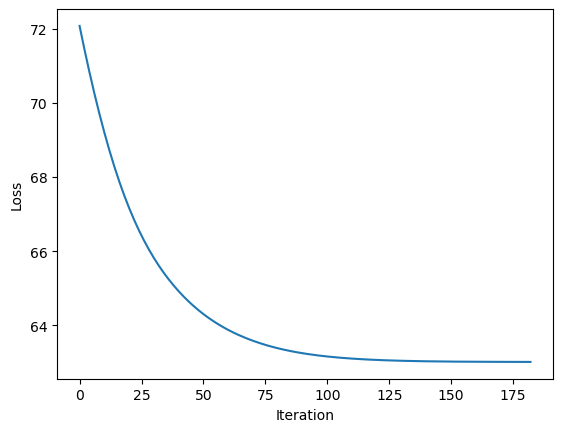

In [7]:
w_MAP_simple, losses = find_MAP(features_simple(X_train), y_train)
plt.plot(losses);
plt.xlabel("Iteration")
plt.ylabel("Loss");
plt.show()

Convergence reached at iteration 394


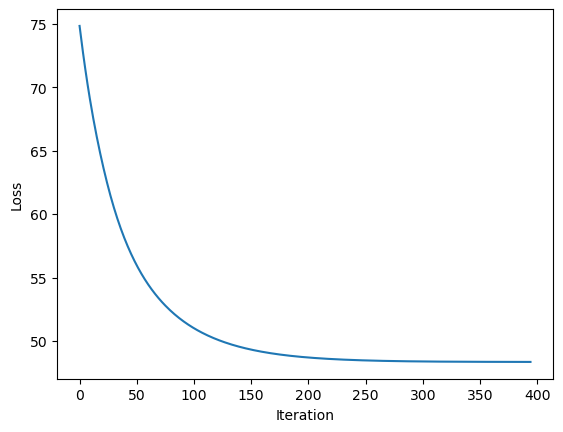

In [8]:
w_MAP_quad, losses = find_MAP(features_quadratic(X_train), y_train)
plt.plot(losses);
plt.xlabel("Iteration")
plt.ylabel("Loss");
plt.show()

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

## Visualization: The following code visualizes the classifier result

It plots the probability of being one class or the other using a color contour plot.

The decision boundary is a dashed black line.

In [9]:
def plot_boundary(X, y, pred):
    h = 0.2
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = pred(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=.8, levels=np.linspace(0, 1, 8))
    
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    
    plt.contour(xx, yy, Z, levels=(0.5,), linestyles='dashed');
    
    # Plot the testing points
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.show()

In [10]:
def plot_boundary(X, y, pred):
    h = 0.2
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Creating the grid points specifically for plotting
    grid_points = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    # Pass grid_points through the `pred` function to get predicted values over the grid
    Z = pred(grid_points).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, levels=np.linspace(0, 1, 8))
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.contour(xx, yy, Z, levels=(0.5,), linestyles='dashed')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.show()

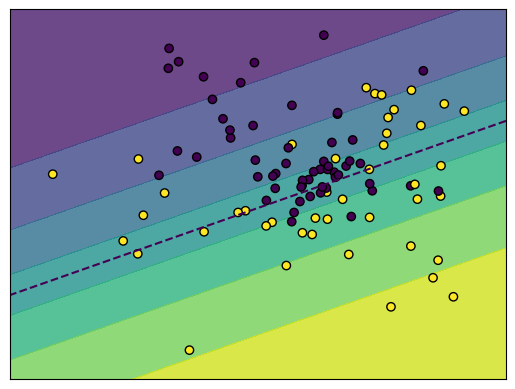

Simple features: training accuracy = 0.68, test accuracy = 0.68


In [11]:
plot_boundary(X_train, y_train, 
              lambda X: predict_probs_MAP(features_simple(X), w_MAP_simple))
plt.title("MAP estimate, simple features")
train_accuracy = (predict_probs_MAP(features_simple(X_train), w_MAP_simple).round() == y_train).float().mean()
test_accuracy = (predict_probs_MAP(features_simple(X_test), w_MAP_simple).round() == y_test).float().mean()
print("Simple features: training accuracy = %0.2f, test accuracy = %0.2f" % (train_accuracy, test_accuracy))

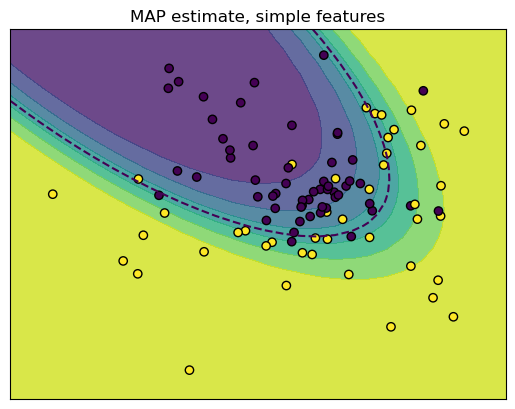

Polynomial features: training accuracy = 0.86, test accuracy = 0.90


In [12]:
plot_boundary(X_train, y_train,
              lambda X: predict_probs_MAP(features_quadratic(X), w_MAP_quad))
plt.title("MAP estimate, quadratic features")
train_accuracy = (predict_probs_MAP(features_quadratic(X_train), w_MAP_quad).round() == y_train).float().mean()
test_accuracy = (predict_probs_MAP(features_quadratic(X_test), w_MAP_quad).round() == y_test).float().mean()
print("Polynomial features: training accuracy = %0.2f, test accuracy = %0.2f" % (train_accuracy, test_accuracy))

# TASK #3 (5 points): Laplace approximation

In the next section, you will fit an approximate posterior over the weights by using the Laplace approximation around the mode $\mathbf{w}_{MAP}$ of the distribution you found above.

This requires completing two functions:

1. `compute_laplace_Cov` takes the data and the MAP estimate, and outputs a covariance matrix defined as the negative inverse Hessian of the log target density. (See the week 4 lecture slides for details on how to compute this!)
2. `predict_bayes` makes predictions on new data points, by approximating $\int p(y | x, w)p(w | \mathcal{D})dw$ when using a Gaussian approximation to $p(w | \mathcal{D})$. In the week 4 lecture slides we discussed three different ways of computing this — it is up to you to decide what method you would prefer, and implement it.

In [13]:
def compute_laplace_Cov(Phi, y, w_MAP, prior_std=10):
    """
    Compute the Laplace approximation of the posterior covariance 
    in a logistic regression setting.
    
    INPUT:
    Phi   : (N, D) tensor of input features, where N is the number of 
            observations and D is the number of features
    y     : (N,) vector of outputs (targets). Should be a `torch.FloatTensor`
            containing zeros and ones
    w_MAP : (D,) vector of optimized weights, at a mode of the target density
    sigma : scalar, standard deviation of Gaussian prior distribution p(w).
            Leave this set to sigma=10 for purposes of this exercise

    OUTPUT:
    Cov : (D, D) posterior covariance matrix estimate defined by the Laplace 
          approximation
    """
    
    # YOUR CODE HERE
    D = w_MAP.shape[0]
    sigma_squared = prior_std ** 2


    #Since PyTorch’s autograd tools typically perform optimization by minimizing a target function, we transform the problem of maximizing the log posterior into a minimization problem. 
    #Hence, we define neg_log_posterior, the negative log posterior,

    #First, I define the negative log-posterior function to compute the Hessian matrix
    def neg_log_posterior(w):
        log_joint_val = log_joint(Phi, y, w, sigma=10)
        return -log_joint_val
    
    #Then, I compute the Hessian matrix of the negative log-posterior at w_MAP
    H = torch.autograd.functional.hessian(neg_log_posterior, w_MAP)

    ##Lastly, I compute the Laplace approximation covariance as the inverse of the Hessian matrix.
    ## I add a small regularization term as diagonal value to ensure invertibility
    #Cov = torch.linalg.inv(H + 1e-6 * torch.eye(D))

    # Regularize the Hessian by adding 1/sigma^2 to the diagonal elements
    H_reg = H + torch.eye(D) / sigma_squared

    # Compute the Laplace approximation covariance as the inverse of the Hessian
    Cov = torch.linalg.inv(H_reg)
    
    return Cov

In [14]:
#Among the possible approaches, I choose to apply the Monte Carlo Sampling that draws samples from N(w_MAP, Cov), 
#computes the predictions for each sample and averages them.

def predict_bayes(Phi, w_MAP, Cov):
    """
    Make predictions on new data points using an approximate posterior 
    w ~ MultivariateNormal(w_MAP, Cov)
    
    INPUT:
    Phi   : (N, D) tensor of input features, where N is the number of 
            observations and D is the number of features
    w_MAP : (D,) vector of optimized weights, at a mode of the target density
    Cov   : (D, D) approximate posterior covariance matrix
    
    OUTPUT:
    y_hat : (N,) vector of probabilities p(y=1 | Phi)
    """
    
    # YOUR CODE HERE
    #Ensuring correct tensor type
    w_MAP = w_MAP.to(torch.float32)
    Cov = Cov.to(torch.float32)
    Phi = Phi.to(torch.float32)
    D = w_MAP.shape[0]

    # Ensure w_MAP is of shape (D,) and Cov is (D, D)
    assert w_MAP.shape == (Phi.shape[1],), f"w_MAP should have shape (D,) but has shape {w_MAP.shape}"
    assert Cov.shape == (Phi.shape[1], Phi.shape[1]), f"Cov should have shape (D, D) but has shape {Cov.shape}"

    #Defining the number of samples (int) to draw from the posterior for prediction
    num_samples = 10000

    #Creating a Multivariate Normal distribution with w_MAP and Cov as parameters
    
    posterior_dist = dist.MultivariateNormal(w_MAP,Cov)

    #Drawing samples from the posterior distribution with shape (num_samples, D)
    samples = posterior_dist.sample((num_samples,))

    #Computing predictions for each sample (shape: (N, num_samples))
    predictions = torch.sigmoid(Phi @ samples.T)

    #Averaging the predictions across all samples to get the final Bayesian estimate (shape: (N,))
    y_hat = predictions.mean(dim=1)

    return y_hat

### The following cells call your functions above to compute the Laplace approximation and visualize the posterior predictive distribution.

In [15]:
Cov_simple = compute_laplace_Cov(features_simple(X_train), y_train, w_MAP_simple)

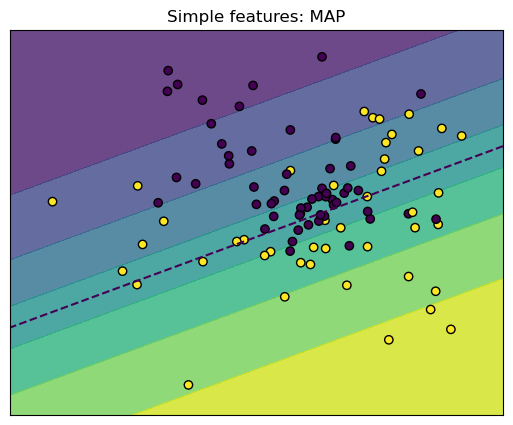

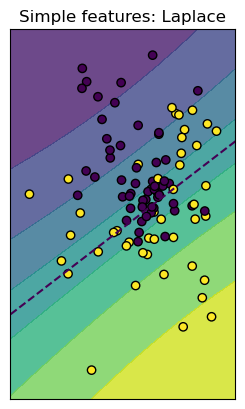

In [17]:
plt.figure(figsize=(14,5))

plt.subplot(121)
plt.title("Simple features: MAP")
plot_boundary(X_train, y_train, 
              lambda X: predict_probs_MAP(features_simple(X), w_MAP_simple))

plt.subplot(122)
plt.title("Simple features: Laplace")
plot_boundary(X_train, y_train, 
              lambda X: predict_bayes(features_simple(X), w_MAP_simple, Cov_simple))
plt.show()

In [18]:
Cov_quad = compute_laplace_Cov(features_quadratic(X_train), y_train, w_MAP_quad)

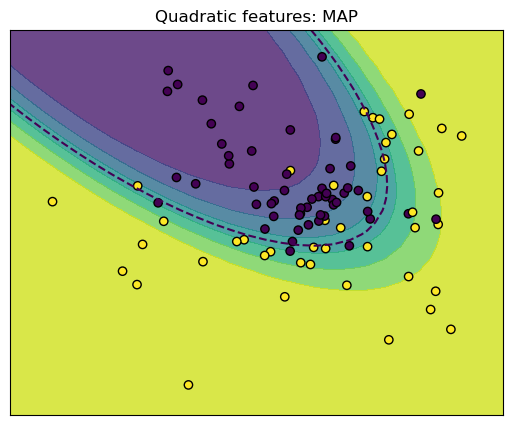

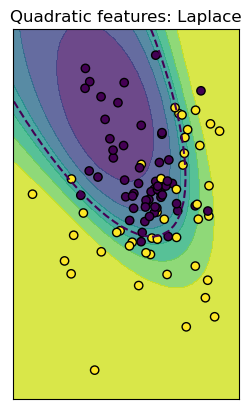

In [19]:
plt.figure(figsize=(14,5))

plt.subplot(121)
plt.title("Quadratic features: MAP")
plot_boundary(X_train, y_train, 
              lambda X: predict_probs_MAP(features_quadratic(X), w_MAP_quad))

plt.subplot(122)
plt.title("Quadratic features: Laplace")
plot_boundary(X_train, y_train, 
              lambda X: predict_bayes(features_quadratic(X), w_MAP_quad, Cov_quad))
plt.show()

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)

# TASK #4 (2 points): Model comparison

You can compute the marginal likelihood approximation defined by the Laplace approximation.

This estimate of the evidence can be used, even just looking at the training data, to help decide which of the two feature maps is more appropriate and better fits the data.

This can help guard against potential overfitting if using features that are "too complex".

In [20]:
def compute_laplace_log_evidence(Phi, y, w_MAP, Cov):
    """
    This computes the Laplace approximation to the marginal likelihood,
    as defined in the Week 5 lectures.
    
    INPUT:
    Phi   : (N, D) tensor of input features, where N is the number of 
            observations and D is the number of features
    y     : (N,) vector of outputs (targets). Should be a `torch.FloatTensor`
            containing zeros and ones
    w_MAP : (D,) vector of optimized weights, at a mode of the target density
    Cov   : (D, D) approximate posterior covariance matrix
    
    OUTPUT:
    log_evidence : scalar value estimating `log p(y | Phi)`
    """
    
    # YOUR CODE HERE
    #The marginal likelihood log p(y | Phi) is approximated in the laplace method as the log joint probability
    #at w_MAP - 0.5 * log * the determinant of Hessian matrix H of the log posterior evaluated at w_MAP adding the normalizing constant - D/2 log(2pi)


    # Computing the log joint probability at w_MAP 
    prior_std = 10.0
    log_joint_val = log_joint(Phi, y, w_MAP, sigma=prior_std)

    #Computing the determinant of the Hessian matrix through the Covariance matrix
    #Since Cov = -H**-1, we take the log of the determinant of Cov that indirectly reflects the determinant of the Hessian matrix 

    log_det_cov = -torch.logdet(Cov)

    #Computing log evidence approximation using the Laplace method
    D = w_MAP.shape[0]
    log_evidence = log_joint_val + 0.5 * log_det_cov - 0.5 * D * torch.log(torch.tensor(2 * torch.pi))
     
    return log_evidence

In [21]:
print("Model evidence estimate (simple features):",
      compute_laplace_log_evidence(features_simple(X_train), y_train, w_MAP_simple, Cov_simple).item())

print("Model evidence estimate (polynomial features):",
      compute_laplace_log_evidence(features_quadratic(X_train), y_train, w_MAP_quad, Cov_quad).item())

Model evidence estimate (simple features): -67.8897705078125
Model evidence estimate (polynomial features): -57.61421203613281


In [ ]:
# (GRADING)

# TASK #5 (2 points + 4 points): Define your own feature space

Your next task is to define your own, custom feature space! This can be practically any deterministic function from $\mathbb{R}^2$ to $\mathbb{R}^D$, and you even get to pick the dimensionality $D$.

In the following cells, you first define your feature space, and then we estimate the posterior using your code above. We report training accuracy, test accuracy, and model evidence, as well as plot the decision boundaries.

Feel free to get quite creative here! However, you will be asked to defend your choice of feature space in the free-answer section at the bottom.

**Make sure when you submit, you include whatever you consider the "best" possible choice!**

In [22]:
#I compute a custom feature map with quadratic terms and RBF terms
def features_student(X):
    """
    Compute your own, custom set of features!
    
    INPUT:
    X      : (N, 2) tensor of raw input data, where each row is [x1, x2]
    
    OUTPUT:
    Phi    : (N, D) tensor of transformed inputs with quadratic and RBF terms
    """
    # Extracting x1 and x2 from the input tensor X
    x1 = X[:, 0]
    x2 = X[:, 1]
    
    # Defineinf fixed centers for the RBF terms chosen within reasonable input range
    centers = torch.tensor([[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]])  # 3 centers (2D)
    
    # Calculating quadratic terms
    x1_squared = x1**2
    x2_squared = x2**2
    
    # Computing pairwise squared distances between data points and the centers
    diff = X.unsqueeze(1) - centers  # Shape: (N, C, 2) where C = number of centers
    dist_sq = (diff ** 2).sum(-1)  # Shape: (N, C), squared distances
    
    # Applying RBF transformation
    gamma = 1.0  # Setting a scaling factor for RBF kernel
    rbf_terms = torch.exp(-gamma * dist_sq)  # Computing the RBF transformed features
    
    # Concatenating bias, original features, quadratic terms, and RBF terms
    Phi = torch.cat([torch.ones_like(x1).unsqueeze(1),   # Bias term (1)
                     X,                                  # Original features (x1, x2)
                     x1_squared.unsqueeze(1),            # Quadratic term for x1
                     x2_squared.unsqueeze(1),            # Quadratic term for x2
                     rbf_terms], dim=1)                 # RBF terms
    
    return Phi.to(torch.float32) 


Convergence reached at iteration 547


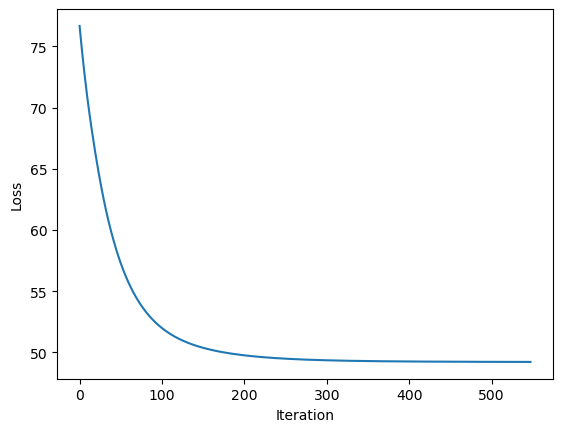

In [23]:
w_MAP_student, losses = find_MAP(features_student(X_train), y_train)
plt.plot(losses);
plt.xlabel("Iteration")
plt.ylabel("Loss");
plt.show()

In [24]:
train_accuracy = (predict_probs_MAP(features_student(X_train), w_MAP_student).round() == y_train).float().mean()
test_accuracy = (predict_probs_MAP(features_student(X_test), w_MAP_student).round() == y_test).float().mean()
print("YOUR features! Training accuracy = %0.2f, test accuracy = %0.2f" % (train_accuracy, test_accuracy))



YOUR features! Training accuracy = 0.86, test accuracy = 0.92


In [25]:
Cov_student = compute_laplace_Cov(features_student(X_train), y_train, w_MAP_student)

print("YOUR features! Model evidence estimate:",
      compute_laplace_log_evidence(features_student(X_train), y_train, w_MAP_student, Cov_student).item())

YOUR features! Model evidence estimate: -65.34902954101562


In [26]:
w_MAP_student

tensor([-0.8174,  0.6598, -1.4216,  0.5951,  0.3730,  0.6829, -1.5698,  1.6880])

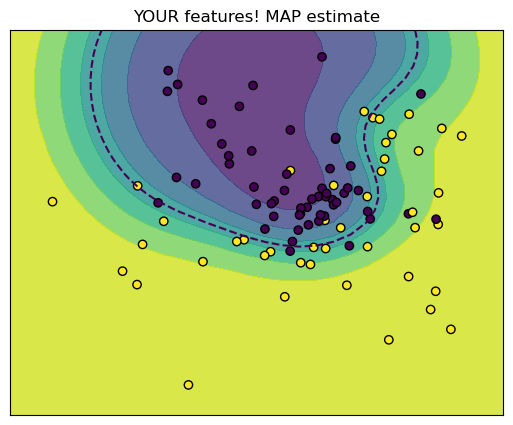

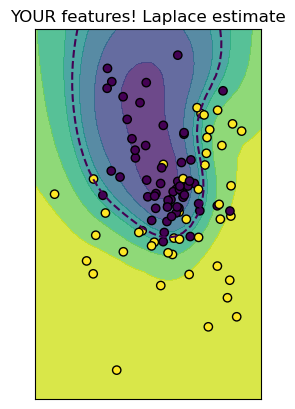

In [27]:
plt.figure(figsize=(14,5))

plt.subplot(121)
plt.title("YOUR features! MAP estimate")
plot_boundary(X_train, y_train, 
              lambda X: predict_probs_MAP(features_student(X), w_MAP_student))

plt.subplot(122)
plt.title("YOUR features! Laplace estimate")
plot_boundary(X_train, y_train, 
              lambda X: predict_bayes(features_student(X), w_MAP_student, Cov_student))
plt.show()

# Please answer the following short questions:

1. *[Feature selection]* How did you choose your features? Name at least two ways of comparing whether one set of features is "better" than another. Would these methods generally yield the same "ranking" of different features? Why or why not?
2. *[Overfitting]* Is "overfitting" possible in this setting? Did you experience it? If so, how would you detect it? Does using the Laplace approximation "help" with overfitting, or does it not make a difference? Justify your answer.

YOUR ANSWER HERE

1. 

The choice of features derived from my observation that quadratic transformations captured the data better than linear features, especially in regions where the data exhibited more complex, parabolic relationships. I wanted to build on this observation and introduce more flexibility into the quadratic function, particularly to account for points that were incorrectly classified, those that lay beyond the decision boundary where the model seemed to have more local minima.
    
After experimenting with several combinations, I decided to retain quadratic terms, which help capture the parabolic relationships between features, and added Radial Basis Function (RBF) terms to introduce non-linear transformations. This allowed the model to capture more complex, distance-based relationships between data points and fixed centers. The choice of centers was made based on common values reasonable with the previous results.
    
To compare the effectiveness of different feature maps, I would consider different methods:
- One involves evaluating the model performance in different feature sets, computing metrics like accuracy, losses or log-likelihood. A higher accuracy and lower loss generally indicate better performance.
- Model evidence is also a common metric in the Bayesian settings. The model evidence provides insight into the model's ability to explain the data while avoiding excessive complexity. A higher model evidence suggests that the model is more likely to generalize well without being overly complex. 
- Another way to evaluate the choice of features map is by applying feature importance technique.  This involves methods like L1 regularization that helps identify the most relevant features by shrinking the coefficients of less important ones to zero.
    
These methods may not yield the same ranking of feature sets because:
- Model performance focuses on the overall fit of the model, but it doesn't necessarily prioritize the most important features.In fact, a feature set with fewer, more informative features may perform better due to reduced model complexity, even if it doesn't include the most important features overall. These methods reward models that generalize well, which tend to avoid overfitting. In contrast, model evidence penalizes overly complex models while rewarding good data fit.
- Feature importance on the other hand might rank differently as they are based on how each feature contributes to reducing model error or variance. The rankings might change depending on how much interaction or correlation exists between the features.

2.

Overfitting is always a possibility when working with machine learning models, especially when the feature space is large or when the model has many parameters relative to the amount of data. 
In this case, using a flexible feature set (like quadratic terms and RBF features) can increase the model's complexity especially if the number of features grows significantly compared to the number of training examples. However, we still have a low number of features compared to the sample size.
    
The obtained accuracy metrics (training accuracy: 86% and test accuracy: 92%) suggest that the model is generalizing well. There is no strong indication of overfitting since the test accuracy is high and exceeds the training accuracy slightly, which typically points to a well-generalizing model.
Nonetheless, visual inspection of the plots reveals that the model fits the training data closely, which could still suggest some degree of overfitting.
     
To detect it I would compare the accuracy metrics across the training and test set: a significantly better model performance on the training set than on the test set is a classic indicator of overfitting.
Also, performing cross-validation can check the model’s performance across different data splits. Large variation in performance between folds could suggest overfitting.
Lastly, plotting the metrics over time (training accuracy and validation loss )could give an indication: if the training performance continues to improve while the validation performance stagnates or worsens, it is a clear signal of overfitting.
    
In Bayesian models, the Laplace approximation provides an estimate of the posterior covariance, which regularizes the model by adding a prior belief about the weights. This approximation can shrink extreme weights, reducing the model's flexibility and complexity. By smoothing out large variations in the posterior, it prevents the model from fitting the noise in the data too closely, which can be a form of overfitting.

However Laplace approximation reduces it but does not directly addresses it, other methods to prevent overfitting could include early stopping during training or adding regularization terms such as L2 regularization.

#### Ignore the following cells. They are used by the grading system.

In [ ]:
# (GRADING)

In [ ]:
# (GRADING)